<a href="https://colab.research.google.com/github/lcmachado16/PLN/blob/master/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Textos com Algoritmos Tradicionais e BoW Features

#Ambiente

In [ ]:
!pip install unidecode

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.5/235.5 kB 5.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
nltk.download('punkt')
nltk.download('stopwords')
from unidecode import unidecode
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn import svm, naive_bayes
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


# Dataset AmericanasBR

https://github.com/americanas-tech/b2w-reviews01/blob/main/b2wreviews01_stil2019.pdf

O dataset original foi simplificado, o campo 'overall_rating' foi usado como 'label':

*   4 e 5 representam positivo (label=1)
*   1 e 2 representam negativo (label=0)
*   rating 3 não foi usado

O dataset resultante originou os dois conjuntos de dados:
*   Treino: usando 5 mil instâncias de cada classe (positivo e negativo).
*   Teste: usando 3 mil instâncias de cada classe excluindo-se instâncias de treino

**Treino e Teste são disjuntos.**



In [ ]:
#baixando os dados de treino e teste
!curl https://www.inf.ufrgs.br/~viviane/DS/B2W-Reviews01_binario5000_TRAIN.csv > B2W-Reviews01_binario5000_TRAIN.csv
!curl https://www.inf.ufrgs.br/~viviane/DS/B2W-Reviews01_binario_TEST.csv > B2W-Reviews01_binario_TEST.csv


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1657k  100 1657k    0     0   579k      0  0:00:02  0:00:02 --:--:--  579k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  981k  100  981k    0     0   374k      0  0:00:02  0:00:02 --:--:--  374k


In [ ]:
df_train = pd.read_csv('B2W-Reviews01_binario5000_TRAIN.csv')
df_test = pd.read_csv('B2W-Reviews01_binario_TEST.csv')

# Explorando o dataset

In [ ]:
df_train.sample(n=5)

,label,text,label_descr
8268,1,Eu gostei muito desse tapete e recomendaria o ...,positivo
3765,0,Nao foi entregue ainda. Esrou esperando tem 2 ...,negativo
9218,1,Muito bom produto. Chegou antes do prazo. Reco...,positivo
5278,1,"Produto funciona excelentemente bem, nada a re...",positivo
1606,0,"Usei tres vezes em um mês e aí parou do nada ,...",negativo


In [ ]:
#está balanceado e possui duas classes:
df_train.groupby('label_descr').count()

,label,text
label_descr,,
negativo,5000,5000
positivo,5000,5000


In [ ]:
df_test.sample(n=5)

,label,text,label_descr
5427,0,A capa vendida não é a mesma exibida na foto d...,negativo
2571,1,"Muito peludo, muito macio, entregou antes do p...",positivo
4618,0,"Ainda não recebi o produto, portanto não o pod...",negativo
1088,1,Atende realmente o que se propõe a fazer. E...,positivo
3627,0,Estou desde o dia 02/01 fazendo contato com Am...,negativo


In [ ]:
#dataset de teste também está balanceado e possui duas classes:
df_test.groupby('label_descr').count()

,label,text
label_descr,,
negativo,3000,3000
positivo,3000,3000


#Pré-processando

In [ ]:
#função de pré-processamento
special_chars = "¨'!#$%&()*+,-./:;<=>?@[\]^_`{|}~"
stop_words = stopwords.words('portuguese')

stop_words.remove('não') # mantém o não na lista de stopwords

def preprocess(x):
    new_x = x.replace('"',' ')
    for c in special_chars:
        new_x = new_x.replace(c,' ')
    new_x = ' '.join([word for word in nltk.word_tokenize(new_x.lower(),language='portuguese') if word not in stop_words]) #removendo stop words
    new_x = re.sub(r'[^\w\s]', ' ', new_x) #removendo pontuação do texto
    new_x = re.sub("http\S+", ' ',new_x) # remove links
    new_x = re.sub("@\w+", ' ',new_x) # remove contas com @
    new_x = re.sub('#\S+', ' ',new_x) # hashtags
    new_x = re.sub('[0-9]+', ' ',new_x) # remove numeros e palavras com numeros
    new_x = unidecode(new_x) #acentos
    new_x = re.sub("\s+", ' ',new_x) # espaços
    new_x = new_x.strip()
    return new_x

#pré-processar datasets de treino e teste
df_train['text_original'] = df_train['text']
df_train['text'] = df_train['text'].apply(preprocess)

df_test['text_original'] = df_test['text']
df_test['text'] = df_test['text'].apply(preprocess)

df_train = df_train.sample(n=len(df_train)).copy() # embaralha treino
df_train.reset_index(drop=True, inplace=True)
len(df_train)

10000

In [ ]:
# remove instâncias com texto com comprimento zero
df_train = df_train[df_train['text']!='']
df_train = df_train[~df_train['text'].isna()]
df_train.reset_index(drop=True, inplace=True) # reindexa dataframe
len(df_train)

9996

# Tarefa 1

1. **Verificação de Duplicidades Internas**: Verifique se existem sentenças duplicadas dentro dos conjuntos de treino e teste separadamente.
   
2. **Verificação de Duplicidades Entre Conjuntos**: Verifique se há sentenças duplicadas presentes tanto no conjunto de treino quanto no de teste.

3. **Remoção de Duplicidades**: Caso sejam encontradas duplicidades, remova-as tanto dentro de cada conjunto quanto entre os conjuntos de treino e teste.

4. **Análise de Impacto**: Apresente o impacto das remoções nos conjuntos de dados, destacando as alterações no tamanho e na distribuição das sentenças.


In [ ]:
# [ SEU CÓDIGO AQUI ]

[ SUA RESPOSTA AQUI ]

#Gerando Representação BoW com pesos TFIDF

Mais informações em https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

In [ ]:
# calcula features e os valores tfidf gerando os vetores dos documentos:
tfidf_vectorizer = TfidfVectorizer()

vetores_docs  = tfidf_vectorizer.fit_transform(df_train['text'].values)
features   = tfidf_vectorizer.get_feature_names_out()
print(features[1:100])
vetores_docs.shape, features.shape

['aaa' 'aaaaaak' 'aaprelho' 'aaptador' 'abacaxi' 'abafado' 'abaixa'
 'abaixando' 'abaixar' 'abaixo' 'abaixou' 'abajur' 'abalada' 'abalar'
 'abandonei' 'abandonou' 'abc' 'abdomem' 'abelhas' 'abencoe' 'aberta'
 'abertas' 'aberto' 'abertos' 'abertura' 'abhp' 'abi' 'abisurdo' 'abnt'
 'abolir' 'aborrecer' 'aborreceu' 'aborrecida' 'aborrecido'
 'aborrecimento' 'abr' 'abra' 'abraca' 'abracadabra' 'abracadeira'
 'abraco' 'abracos' 'abram' 'abrange' 'abre' 'abrem' 'abreu' 'abreviado'
 'abri' 'abria' 'abrigada' 'abril' 'abrimos' 'abrindo' 'abrir' 'abriram'
 'abrirmos' 'abriu' 'abro' 'abs' 'absolut' 'absolutamente' 'absorcao'
 'absorto' 'absorve' 'absorvendo' 'absorvicao' 'absurda' 'absurdamente'
 'absurdo' 'absurdoooo' 'absurdooooo' 'absurdos' 'abusivo' 'abuso'
 'abusurdo' 'acaba' 'acabada' 'acabadas' 'acabado' 'acabam' 'acabamente'
 'acabamento' 'acabamentos' 'acabamos' 'acabando' 'acabar' 'acabaram'
 'acabe' 'acabei' 'acabem' 'acabo' 'acabou' 'academia' 'academico'
 'academicos' 'acampamento' 

((9996, 13286), (13286,))

In [ ]:
# # opções de preprocessamento que sobrescrevem funcoes do tfidftokenizer:

# tfidf_vectorizer = TfidfVectorizer(input='filename', max_features=200,
#                            token_pattern='(?u)\\b[a-zA-Z]\\w{2,}\\b',
#                            max_df=0.05,
#                            stop_words='english',
#                            ngram_range=(1, 3))


# def meu_preprocessamento(doc):
#     # tokeniza com algum toeknizador
#     # adiciona funcoes de preprocessamento
#     return doc
#
# tfidf = TfidfVectorizer(
#     analyzer='word',
#     tokenizer=meu_tokenizador,
#     preprocessor=meu_tokenizador,
#     token_pattern=None)



## Analisando os vetores gerados

In [ ]:
doc_id = 0
vetores_docs[doc_id]

<1x13286 sparse matrix of type '<class 'numpy.float64'>'
	with 8 stored elements in Compressed Sparse Row format>

In [ ]:
#features e valores tfidf pertencentes ao 1o documento (indice 0)
print(vetores_docs[doc_id])

  (0, 10175)	0.10407087639357106
  (0, 1746)	0.18065119082281844
  (0, 9739)	0.33375015040961586
  (0, 12241)	0.2504615178968555
  (0, 8973)	0.3651688100041569
  (0, 3596)	0.3840055766402062
  (0, 7795)	0.45523806917710063
  (0, 3940)	0.5425532441858676


In [ ]:
# outra forma de lidar com esses vetores comprimidos é expandir os mesmos
# verificando o documento (d1)
print('Documento1: ',df_train.at[doc_id,'text'])
d1 = vetores_docs[doc_id].toarray()[0]
print('tamanho do vetor d1:', len(d1))
print(d1)

Documento1:  produto bom poderia ter opcao deixar luzes desligadas
tamanho do vetor d1: 13286
[0. 0. 0. ... 0. 0. 0.]


In [ ]:
# no vetor expandido do documento d1 as features que realmente existem no vetor são:
ids = np.argwhere(d1>0)
ids = np.transpose(ids)[0]
print(ids)

[ 1746  3596  3940  7795  8973  9739 10175 12241]


In [ ]:
d1[ids[0]], features[ids[0]]

(0.18065119082281844, 'bom')

In [ ]:
print('Documento d1: ',df_train.at[doc_id,'text'])
print('>>> as features que existem em d1 são:')
print(features[ids])
print('>>> tfidf das features de d1 são: ')
print(d1[ids])

Documento d1:  aguardando receber produto nao posso fazer nenhuma avaliacao
>>> as features que existem em d1 são:
['aguardando' 'avaliacao' 'fazer' 'nao' 'nenhuma' 'posso' 'produto'
 'receber']
>>> tfidf das features de d1 são: 
[0.40930549 0.44984879 0.34983374 0.14274602 0.40164651 0.38505164
 0.13687226 0.39878103]


In [ ]:
# podemos expandir toda a matriz tfidf:
m = vetores_docs.toarray()
print(f'Matriz tfidf (linhas=docs, colunas=features): {m.shape}')
# visualizando a matriz esparsa tfidf: LINHAS = DOCUMENTOS, COLUNAS = FEATURES = TOKENS
dfM = pd.DataFrame(m)
dfM

Matriz tfidf (linhas=docs, colunas=features): (9996, 13286)


,0,1,2,3,4,5,6,7,8,9,...,13276,13277,13278,13279,13280,13281,13282,13283,13284,13285
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9992,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9993,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9994,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# imprimindo as palavas e seus índices
#for w in dict(enumerate(features)):
 #  print(w, dict(enumerate(features))[w])


In [ ]:
# obtendo o token a partir do id (nr da coluna)
id_palavra = 7178 #palavra "inutil" 7178
featuresId=dict(enumerate(features))
featuresId[id_palavra]

'inutil'

In [ ]:
# Em quantos documentos (document frequency) esse token está presente e qual o valor do score
print(f"O token <{features[id_palavra]}> aparece em {len(dfM[dfM[id_palavra]>0][id_palavra])} documento(s):")
dfM[dfM[id_palavra]>0][id_palavra]


O token <inutil> aparece em 6 documento(s):


,7178
1983,0.284605
2411,0.218638
2823,0.239491
5037,0.310761
5084,0.527104
9336,0.236327


## Visualizando TFIDF

In [ ]:
vetores_docs.shape, tfidf_vectorizer.idf_.shape

((9996, 13286), (13286,))

In [ ]:
idf_scores = tfidf_vectorizer.idf_

In [ ]:
dfidf = pd.DataFrame({'idf':idf_scores,'words':tfidf_vectorizer.get_feature_names_out()})

In [ ]:
dfidf.sort_values(by=['idf'],ascending=False, inplace=True)

In [ ]:
# importância das palavras no corpus
dfidf

,idf,words
13285,9.516893,zzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzzz...
5002,9.516893,equivocada
4970,9.516893,envolver
9560,9.516893,pessado
4968,9.516893,envolvendo
...,...,...
1746,3.033786,bom
4900,2.827294,entrega
10731,2.787667,recomendo
8566,1.822728,nao


In [ ]:
# valores de idf e quantidade de palavras
dfidf.groupby(['idf']).count().sort_values(by=['idf'],ascending=False).head(10)

,words
idf,
9.516893,6863
9.111428,1899
8.823746,857
8.600602,592
8.418281,381
8.264130,261
8.130599,248
8.012816,174
7.907455,168


<Axes: >

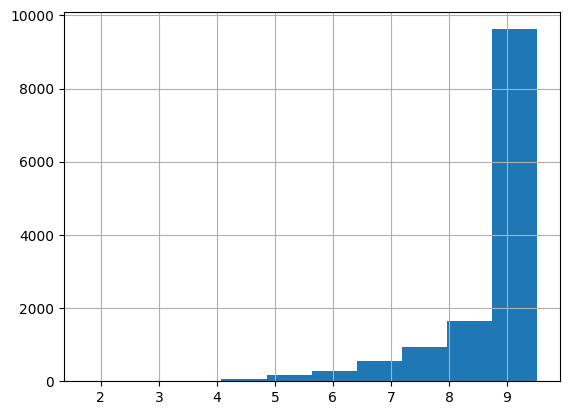

In [ ]:
dfidf['idf'].hist()

/usr/local/lib/python3.10/dist-packages/yellowbrick/text/tsne.py:401: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  self.ax.scatter(


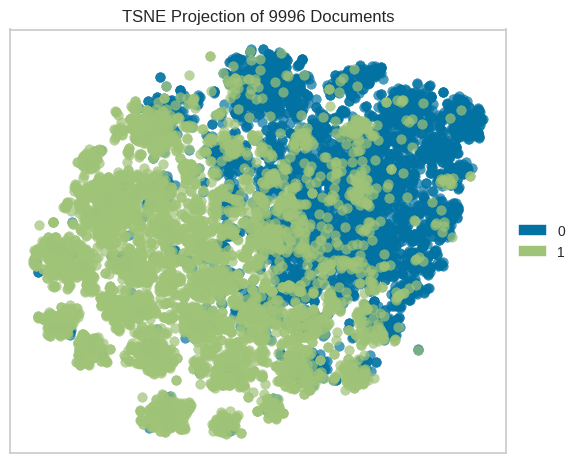

<Axes: title={'center': 'TSNE Projection of 9996 Documents'}>

In [ ]:
%%time
#visualizando espacialmente os vetores tfidf reduzidos a duas dimensoes (demora para executar):
from yellowbrick.text import TSNEVisualizer

tfidf = TfidfVectorizer()
X = tfidf.fit_transform(df_train['text'].values)
y = df_train['label'].values

# Create the visualizer and draw the vectors
tsne = TSNEVisualizer(random_state=42) # random_state para reprodutibilidade das projeções em 2D
tsne.fit(X, y)
tsne.show()

# Treinando Modelo de Classificação

In [ ]:
df_train.groupby(['label_descr', 'label']).count()

CPU times: user 2min 11s, sys: 801 ms, total: 2min 12s
Wall time: 2min 32s


,,text,text_original
label_descr,label,,
negativo,0,4999,4999
positivo,1,4997,4997


In [ ]:
# Gerando a representação vetorial para os textos da base de treino
vectorizer = TfidfVectorizer()
#fit_transform ajusta o vetorizador tfidf à base de treino e também transforma o texto em X
X = vectorizer.fit_transform(list(df_train['text']))
y = np.array(df_train['label'])

In [ ]:
#efetuar o treinamento usando parâmetros predeterminados
#clf = svm.SVC(C=1.0, kernel='linear', degree=3, gamma='auto')
#efetuar o treinamento usando parâmetros default
clf = svm.SVC()
clf.fit(X, y)

SVC()

In [ ]:
# efetuar o treinamento fazendo refit com a melhor configuração:
#model = svm.SVC()
#parameters = {'kernel':['linear','rbf'], 'C':[1, 5]} # neste caso estaremos variando o parâmetro 'C' e 'Kernel' do algoritmo svm
#clf = GridSearchCV(estimator=model, param_grid=parameters, cv=5, verbose=4, scoring=('accuracy','f1_macro'), refit='accuracy')
#clf.fit(X, y)
#print(f"Para {model} melhor score {clf.best_score_:.3f} para os seguintes parâmetros: {clf.best_params_}")

##Prevendo a classe das instâncias de teste

In [ ]:
# Gerando a representação vetorial para os textos da base de teste
X_true = vectorizer.transform(df_test['text'].values) #somente transform usando vocabulario do treino
y_true = df_test['label'].values
# gera as predições para os dados de teste:
y_pred = clf.predict(X_true)

In [ ]:
y_pred[0:15]

array([1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1])

##Avaliando a Qualidade do Modelo

Acurácia: 0.9333
F1-macro: 0.9333


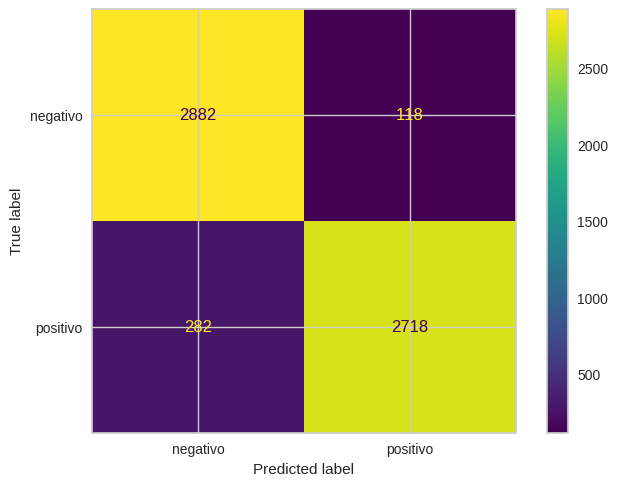

In [ ]:
print(f"Acurácia: {accuracy_score(y_true, y_pred):.4f}")
print(f"F1-macro: {f1_score(y_true, y_pred, average='macro'):.4f}")
cm = confusion_matrix(y_true, y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = list(df_train.label_descr.unique()))
cm_display.plot()
plt.show()

# Tarefa 2

1. **Treinamento com Naive Bayes**: Realize o treinamento do corpus utilizando o algoritmo Naive Bayes.

2. **Comparação com SVM**: Compare os resultados obtidos com o classificador SVM treinado no mesmo corpus.

3. **Análise de Desempenho**: Avalie as diferenças de desempenho entre os dois classificadores com base nas seguintes análises:
   - Matriz de confusão
   - Métricas de F1-score
   - Acurácia

4. **Discussão das Diferenças**: Identifique e discuta as principais diferenças observadas nos resultados.


In [ ]:
# [ SEU CÓDIGO AQUI ]

[ SUA RESPOSTA AQUI ]

##Examinando os as instâncias mal classificadas

In [ ]:
erros  = list (zip(df_test['text'].values,df_test['text_original'].values,y_true,y_pred)) #criando lista com os erros
erros = [item for item in erros if item[2] != item[3]] #removendo as instâncias corretas
df_erros = pd.DataFrame(erros,columns =['Texto','Original','True','Pred']) #gerando um dataframe para ficar mais fácil de trabalhar

In [ ]:
#acrescentando colunas FP e FN no dataframe com os erros
df_erros['FP'] = df_erros.apply(lambda x: 1 if ((x['Pred']==1) & (x['True']==0)) else 0, axis=1)
df_erros['FN'] = df_erros.apply(lambda x: 1 if ((x['Pred']==0) & (x['True']==1)) else 0, axis=1)

In [ ]:
print('Há ', len(df_erros),' instâncias mal classificadas.')

Há  400  instâncias mal classificadas.


In [ ]:
df_erros[df_erros['FN']==1]

,Texto,Original,True,Pred,FP,FN
0,chegou antes prazo caneta fininha nao falha es...,"Chegou antes do prazo, a caneta é fininha e na...",1,0,0,1
1,comprei entrega jato entregar dia util comprei...,Comprei entrega a jato para entregar em 1 dia ...,1,0,0,1
2,funciona faz pipoca rapida saudavel nao desper...,"Funciona mesmo. Faz pipoca rápida, saudável e ...",1,0,0,1
3,melhor tons po mandam avaliar criam dificuldad...,"melhor que 50 tons , pô vocês mandam avaliar m...",1,0,0,1
4,agradei aparelho vi alguns tutoriais internet ...,Agradei do aparelho. Vi alguns tutoriais na in...,1,0,0,1
...,...,...,...,...,...,...
277,bem legal celular tela grande bateria dura des...,"Bem legal o celular, tela grande, bateria du...",1,0,0,1
278,bicicleta boa porem nao pega cambio traseiro r...,A bicicleta é muito boa porém não pega câmbio ...,1,0,0,1
279,melhor pc ever compreee oque ta esperando vai ...,melhor pc ever compreee.Oque se ta esperando v...,1,0,0,1
280,apesar nvi nao traducao preferida biblia cumpr...,Apesar da NVI não ser a minha tradução preferi...,1,0,0,1


In [ ]:
df_erros[df_erros['FP']==1]

,Texto,Original,True,Pred,FP,FN
282,comprei interesse principalmente proteger cama...,Eu comprei no interesse de principalmente de p...,0,1,1,0
283,comprei final novembro volta dia recebi dei na...,Comprei no final de novembro por volta do dia ...,0,1,1,0
284,excelente produto otimo preco comprei colocar ...,"Um excelente produto, ótimo preço, comprei par...",0,1,1,0
285,celular otimo desempenho cumpre promete compre...,O celular tem um ótimo desempenho. Cumpre o q...,0,1,1,0
286,material excelente qualidade boca defeito acen...,"Material é de excelente qualidade, mas uma boc...",0,1,1,0
...,...,...,...,...,...,...
395,produto eh lindo problema entrega muita demora...,O produto eh lindo. O problema foi a entrega. ...,0,1,1,0
396,gostei camera designer otimo nao trava nao gos...,"Gostei câmera, designer e ótimo ,não trava o q...",0,1,1,0
397,prnsei vidro qualidade bem ruim quer algo simp...,Prnsei que fosse de vidro e qualidade bem ruim...,0,1,1,0
398,nao aprovei produto questoes qualidade cor ach...,Não aprovei o produto pelas questões da qualid...,0,1,1,0


In [ ]:
#salvando csv com as instâncias mal classificadas
from google.colab import drive
drive.mount('/content/drive')
path = '/content/drive/MyDrive/Colab Notebooks/erros_americanas.csv'
df_erros.to_csv(path)

Mounted at /content/drive


# Tarefa 3

1. **Análise de Erros do Naive Bayes**: Realize uma análise detalhada dos erros cometidos pelo classificador Naive Bayes, seguindo o mesmo procedimento adotado anteriormente para o SVM.

2. **Verificação de Interseção de Erros**: Verifique se há interseção entre as classificações incorretas de ambos os classificadores (Naive Bayes e SVM), use o diagram de Venn como apoio visual. Identifique quais frases foram classificadas de forma errada por ambos.

3. **Comparação de Resultados**: Analise se há alguma característica distinta nos erros de cada classificador. Discuta se o tipo de erro cometido pelo Naive Bayes difere dos erros cometidos pelo SVM e, se sim, explore as possíveis causas dessas diferenças.

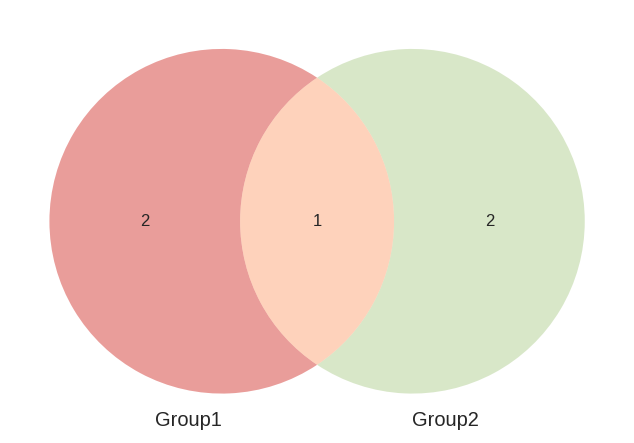

In [ ]:
# Exemplo de código para a criação do diagram de Venn

import matplotlib.pyplot as plt
from matplotlib_venn import venn2

set1 = set(['A', 'B', 'C'])
set2 = set(['A', 'E', 'F'])

venn2([set1, set2], ('Group1', 'Group2'))

plt.show()

In [ ]:
# [ SEU CÓDIGO AQUI ]

[ SUA RESPOSTA AQUI ]

#O problema das palavras fora do vocabulário OOV

In [ ]:
#retorna o vocabulário do dataset
def vocabulario (texto):
  tokens_nltk = []
  for t in texto.values:
    tokens_nltk.extend(nltk.word_tokenize(t, language='portuguese'))
  tokens_distintos = set(tokens_nltk)
  return tokens_distintos

vocab_train = vocabulario(df_train['text'])
vocab_test = vocabulario(df_test['text'])


In [ ]:
#tamanho do vocabulário de treino e teste
print (len(vocab_train))
print (len(vocab_test))

13311
10213


In [ ]:
oov = vocab_test.difference(vocab_train) #oov tem as palavras que aparecem no teste mas não no treino

In [ ]:
print('Número de palavras que estão no teste e não no treino (OOV):',len(oov))

Número de palavras que estão no teste e não no treino (OOV): 3604


In [ ]:
oov = list(oov) #transformando o conjunto em lista
oov.sort() #ordenando a lista

In [ ]:
#imprimindo as oovs
oov[400:600]

['barbar',
 'barbas',
 'barber',
 'barelhenta',
 'barra',
 'barulhentas',
 'barulhos',
 'basa',
 'baseada',
 'bastantes',
 'bastaria',
 'bastemp',
 'bata',
 'batalhas',
 'batch',
 'bateira',
 'batons',
 'baunilha',
 'bayer',
 'bebedor',
 'beewii',
 'beijo',
 'beijos',
 'beliche',
 'bendito',
 'benificio',
 'best',
 'besteirol',
 'bfo',
 'bhosta',
 'bichos',
 'big',
 'bijuterias',
 'biom',
 'bios',
 'biquini',
 'bisnaga',
 'bistro',
 'bits',
 'bizantino',
 'blabla',
 'blindada',
 'blocos',
 'bloqueada',
 'blu',
 'bluegame',
 'blues',
 'bluetooh',
 'bluray',
 'blush',
 'blusinhas',
 'bmw',
 'boba',
 'bobina',
 'bocado',
 'bocais',
 'bolada',
 'bolado',
 'bolar',
 'bolsonaro',
 'bommmmm',
 'bommmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmmm',
 'bon',
 'bonequinhos',
 'bonificacao',
 'book',
 'booooooooooooooooooooooooooooooooooooooooooooooooooooooooom',
 'bordados',
 'borrado',
 'borram',
 'bose',
 'bost',
 'botijao',
 'botox',
 'boua',
 'bp',
 'bpta',
 'branquinho',
 'bras',
 